In [9]:
import pandas as pd

# Judge Analysis

In [64]:
df_oracle = pd.read_csv("outputs/judge_oracle_summary.csv")
df_pruner = pd.read_csv("outputs/judge_pruner_summary.csv")

# Filter _ont
df_oracle = df_oracle[~df_oracle['experiment'].str.contains('_ont')]
df_pruner = df_pruner[~df_pruner['experiment'].str.contains('_ont')]

df_oracle['dataset'] = df_oracle['target_id'].apply(lambda x: x.split(":")[0])
df_pruner['dataset'] = df_pruner['target_id'].apply(lambda x: x.split(":")[0])

In [ ]:
exps_with_kickoff = df_oracle[df_oracle['experiment'].str.contains('kickoff')]['experiment'].unique()

exps_with_kickoff

array(['diseases_160_nemotron8b_fo_cot_with_kickoff',
       'diseases_160_nemotron8b_fo_no_cot_with_kickoff',
       'diseases_160_nemotron8b_po_cot_with_kickoff',
       'diseases_160_nemotron8b_po_no_cot_with_kickoff',
       'geo_160_nemotron8b_po_cot_with_kickoff',
       'geo_160_nemotron8b_po_no_cot_with_kickoff',
       'objects_158_nemotron8b_fo_cot_with_kickoff',
       'objects_158_nemotron8b_fo_no_cot_with_kickoff',
       'objects_158_nemotron8b_po_no_cot_with_kickoff',
       'diseases_160_0.6b_po_cot_with_kickoff',
       'diseases_160_0.6b_po_no_cot_with_kickoff',
       'geo_160_0.6b_po_cot_with_kickoff',
       'geo_160_0.6b_po_no_cot_with_kickoff',
       'objects_158_0.6b_po_cot_with_kickoff',
       'objects_158_0.6b_po_no_cot_with_kickoff'], dtype=object)

In [54]:
df_pruner

,conversation_path,judge_eval_path,experiment,target_id,target_label,seeker_model,oracle_model,pruner_model,judge_model,n_turns,n_ok,n_errors,mean_jaccard,n_target_removed_by_qwen,n_target_removed_by_judge,dataset
0,models/s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8...,models/s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8...,diseases_160_gemma12b_fo_no_cot,disease:acute_bronchiolitis:2,acute bronchiolitis,Gemma-3-12B-IT,Qwen3-8B,Qwen3-8B,gpt-oss-120b,13,13,0,0.935165,0,0,disease
1,models/s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8...,models/s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8...,diseases_160_gemma12b_fo_no_cot,disease:anemia_due_to_chronic_kidney_disease:7,anemia due to chronic kidney disease,Gemma-3-12B-IT,Qwen3-8B,Qwen3-8B,gpt-oss-120b,11,11,0,0.929641,1,1,disease
2,models/s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8...,models/s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8...,diseases_160_gemma12b_fo_no_cot,disease:chorioretinitis:27,chorioretinitis,Gemma-3-12B-IT,Qwen3-8B,Qwen3-8B,gpt-oss-120b,27,27,0,0.862811,1,2,disease
3,models/s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8...,models/s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8...,diseases_160_gemma12b_fo_no_cot,disease:common_cold:30,common cold,Gemma-3-12B-IT,Qwen3-8B,Qwen3-8B,gpt-oss-120b,14,14,0,0.910714,3,3,disease
4,models/s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8...,models/s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8...,diseases_160_gemma12b_fo_no_cot,disease:drug_abuse:38,drug abuse,Gemma-3-12B-IT,Qwen3-8B,Qwen3-8B,gpt-oss-120b,24,24,0,0.938849,4,3,disease
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1499,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...,geo_160_paprika_llama31_8b_fo_no_cot,city:1811103,Foshan,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,gpt-oss-120b,8,8,0,0.928406,0,0,city
1500,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...,geo_160_paprika_llama31_8b_po_no_cot,city:1259229,Pune,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,gpt-oss-120b,30,30,0,0.969068,2,1,city
1501,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...,geo_160_paprika_llama31_8b_po_no_cot,city:1808926,Hangzhou,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,gpt-oss-120b,12,12,0,0.897498,1,0,city
1502,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...,geo_160_paprika_llama31_8b_po_no_cot,city:1815286,Chengdu,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,gpt-oss-120b,22,22,0,0.946374,3,2,city


In [52]:
df_oracle[df_oracle["oracle_model"] == "Qwen3-8B"]['agreement'].mean()

np.float64(0.8972618075323909)

In [55]:
df_pruner[df_pruner["oracle_model"] == "Qwen3-8B"]['mean_jaccard'].mean()

np.float64(0.9087648568149391)

In [50]:
df_oracle[["oracle_model", "dataset", "agreement"]].groupby(["dataset", "oracle_model"]).mean()

agreement
dataset oracle_model                  
city    Gemma-3-12B-IT        0.948052
        Qwen3-8B              0.913328
disease Gemma-3-12B-IT        0.907834
        Nemotron-Cascade-8B   0.951711
        Qwen3-8B              0.870629
object  Gemma-3-12B-IT        0.952589
        Qwen3-8B              0.907232

# Question Classfication

In [1]:
import pandas as pd

df_questions = pd.read_json("outputs/question_classifications.jsonl", lines=True)

# Filter out _ont experiments
df_questions = df_questions[~df_questions['experiment'].str.contains('_ont')]


df_questions['seeker'] = df_questions['model_slug'].str.split("__").str[0].str[2:]

df_questions['oracle'] = df_questions['model_slug'].str.split("__").str[1].str[2:]


df_questions

,turns_path,experiment,model_slug,domain,mode,cot,target,num_turns,turns,analysis_model,seeker,oracle
866,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-abscess_of_nose-0_run01,1,"[{'turn': 1, 'question': '[Turn 1/30] [Compute...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,Qwen3-8B
873,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-macular_degeneration-91_run01,4,"[{'turn': 1, 'question': '[Turn 1/30] [Compute...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,Qwen3-8B
874,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-intertrigo_skin_condition-81_run01,5,"[{'turn': 1, 'question': '[Turn 1/30] [Compute...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,Qwen3-8B
885,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-eating_disorder-41_run01,11,"[{'turn': 1, 'question': '[Turn 1/30] [Compute...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,Qwen3-8B
886,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-hepatic_encephalopathy-61_run01,11,"[{'turn': 1, 'question': '[Turn 1/30] [Compute...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,Qwen3-8B
...,...,...,...,...,...,...,...,...,...,...,...,...
38160,outputs/models/s_paprika_Meta-Llama-3.1-8B-Ins...,objects_158_paprika_llama31_8b_po_no_cot,s_paprika_Meta-Llama-3.1-8B-Instruct__o_Qwen3-...,objects,po,False,object-clothes-9_run01,30,"[{'turn': 1, 'question': 'Is the target object...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B
38161,outputs/models/s_paprika_Meta-Llama-3.1-8B-Ins...,objects_158_paprika_llama31_8b_po_no_cot,s_paprika_Meta-Llama-3.1-8B-Instruct__o_Qwen3-...,objects,po,False,object-fruits-8_run01,30,"[{'turn': 1, 'question': 'Is the target object...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B
38162,outputs/models/s_paprika_Meta-Llama-3.1-8B-Ins...,objects_158_paprika_llama31_8b_po_no_cot,s_paprika_Meta-Llama-3.1-8B-Instruct__o_Qwen3-...,objects,po,False,object-vehicles-7_run01,30,"[{'turn': 1, 'question': 'Is the target object...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B
38163,outputs/models/s_paprika_Meta-Llama-3.1-8B-Ins...,objects_158_paprika_llama31_8b_po_no_cot,s_paprika_Meta-Llama-3.1-8B-Instruct__o_Qwen3-...,objects,po,False,object-office_supplies-12_run01,30,"[{'turn': 1, 'question': 'Is the target object...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B


In [16]:
stratum = ['seeker', 'oracle', 'domain', 'mode', 'cot']


# Explodir turns → 1 linha por turno
turns = df_questions.explode('turns').reset_index(drop=True)

turns['seeker'] = turns['seeker'].str.replace(r'^OLMo-', 'Olmo-', regex=True)


turns = pd.concat([
    turns.drop(columns=['turns']),
    turns['turns'].apply(lambda t: {
        'turn': t.get('turn'),
        'question': t.get('question'),
        'oracle_answer': t.get('oracle_answer'),
        **t.get('classification', {'question_type': 'MISSING', 'redundancy': 'MISSING', 'subclasses': []}),
    }).apply(pd.Series)
], axis=1)

# Flag de redundância
turns['is_redundant'] = turns['redundancy'].isin(['exact_duplicate', 'semantic_equivalent', 'strictly_implied'])

turns

,turns_path,experiment,model_slug,domain,mode,cot,target,num_turns,analysis_model,seeker,...,question,oracle_answer,question_type_rationale,question_type,subclasses_rationale,subclasses,redundancy_rationale,redundancy,error,is_redundant
0,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-abscess_of_nose-0_run01,1,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,...,Do you have a nose abscess?,Yes! You found the target!,"Asks about a specific medical condition, namin...",direct_guess,,[],"This is the first turn, so there is no prior i...",none,NaN,False
1,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-macular_degeneration-91_run01,4,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,...,What is the disease?,No,The question is not a valid yes/no question; i...,malformed,The question is phrased as an open-ended reque...,[open_ended],"This is the first turn, so no prior informatio...",none,NaN,False
2,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-macular_degeneration-91_run01,4,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,...,What is the disease?,No,"The question repeats the same open-ended, non-...",malformed,"Like turn 1, it is an open-ended question, not...",[open_ended],This is a verbatim repeat of the question from...,exact_duplicate,NaN,True
3,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-macular_degeneration-91_run01,4,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,...,What is the disease?,No,"Again, the question is open-ended and not in a...",malformed,Same as previous turns: it requests a name rat...,[open_ended],This repeats the exact same wording as turns 1...,exact_duplicate,NaN,True
4,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-macular_degeneration-91_run01,4,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,...,What is the disease?,"No, the correct answer is macular degeneration...",The question remains open-ended and not a vali...,malformed,Continues the pattern of asking for a direct a...,[open_ended],This is again identical in wording to the ques...,exact_duplicate,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
573324,outputs/models/s_paprika_Meta-Llama-3.1-8B-Ins...,objects_158_paprika_llama31_8b_po_no_cot,s_paprika_Meta-Llama-3.1-8B-Instruct__o_Qwen3-...,objects,po,False,object-clothes-5_run01,30,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,paprika_Meta-Llama-3.1-8B-Instruct,...,Is the target object something that can be fou...,No,Asks about typical location of use in a domest...,semantic,Relates object to a common room (bathroom).,[relational],New spatial context (bathroom) not previously ...,none,NaN,False
573325,outputs/models/s_paprika_Meta-Llama-3.1-8B-Ins...,objects_158_paprika_llama31_8b_po_no_cot,s_paprika_Meta-Llama-3.1-8B-Instruct__o_Qwen3-...,objects,po,False,object-clothes-5_run01,30,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,paprika_Meta-Llama-3.1-8B-Instruct,...,Is the target object related to a type of game?,No,Asks about association with a recreational cat...,semantic,Seeks to place object in a functional category...,[fine_grained_category],New functional context (games) not previously ...,none,NaN,False
573326,outputs/models/s_paprika_Meta-Llama-3.1-8B-Ins...,objects_158_paprika_llama31_8b_po_no_cot,s_paprika_Meta-Llama-3.1-8B-Instruct__o_Qwen3-...,objects,po,False,object-clothes-5_run01,30,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,paprika_Meta-Llama-3.1-8B-Instruct

In [17]:
mask = turns['subclasses'].explode().eq('fine_grained_category').groupby(level=0).any()
turns[(mask) & (turns['domain'].eq('diseases'))]

,turns_path,experiment,model_slug,domain,mode,cot,target,num_turns,analysis_model,seeker,...,question,oracle_answer,question_type_rationale,question_type,subclasses_rationale,subclasses,redundancy_rationale,redundancy,error,is_redundant
24,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-hepatic_encephalopathy-61_run01,11,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,...,Do you have a **neurodegenerative disorder**?,No,Probes a specific subtype of neurological dise...,semantic,Narrows focus within neurological disorders to...,[fine_grained_category],Introduces a more specific neurological subcat...,none,NaN,False
26,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-hepatic_encephalopathy-61_run01,11,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,...,Do you have a **neurodegenerative disorder**?,No,Repeats earlier inquiry about a specific neuro...,semantic,Same fine-grained neurological category as tur...,[fine_grained_category],Identical to turn 4 in wording and meaning; no...,exact_duplicate,NaN,True
29,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-hepatic_encephalopathy-61_run01,11,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,...,Do you have a **neurodegenerative disorder**?,No,Repeats the fine-grained neurological category...,semantic,Same as turns 4 and 6; targets neurodegenerati...,[fine_grained_category],Third instance of this exact question; previou...,exact_duplicate,NaN,True
46,outputs/models/s_Llama-3.2-1B-Instruct__o_Qwen...,diseases_160_llama1b_fo_no_cot,s_Llama-3.2-1B-Instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-common_cold-30_run01,16,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Llama-3.2-1B-Instruct,...,Do you have a thyroid nodule?,No,Asks about a specific medical condition relate...,semantic,Targets a fine-grained medical condition that ...,[fine_grained_category],This is the first mention of thyroid nodules; ...,none,NaN,False
301,outputs/models/s_Nemotron-Cascade-8B__o_Qwen3-...,diseases_160_nemotron8b_fo_cot_with_kickoff,s_Nemotron-Cascade-8B__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,True,disease-abscess_of_nose-0_run01,6,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Nemotron-Cascade-8B,...,Is the target condition characterized by direc...,No,Probes a more specific anatomical involvement ...,semantic,"Focuses on a specific organ (lung), indicating...",[fine_grained_category],"While related to respiratory involvement, this...",none,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564340,outputs/models/s_paprika_Meta-Llama-3.1-8B-Ins...,diseases_160_paprika_llama31_8b_po_no_cot,s_paprika_Meta-Llama-3.1-8B-Instruct__o_Qwen3-...,diseases,po,False,disease-rosacea-125_run01,30,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,paprika_Meta-Llama-3.1-8B-Instruct,...,Is the target disease a form of Gaucher disease?,No,Asks about a specific lysosomal storage disord...,semantic,"Targets a known inherited metabolic condition,...",[fine_grained_category],Gaucher disease has not been previously addres...,none,NaN,False
564395,outputs/models/s_paprika_Meta-Llama-3.1-8B-Ins...,diseases_160_paprika_llama31_8b_po_no_cot,s_paprika_Meta-Llama-3.1-8B-Instruct__o_Qwen3-...,diseases,po,False,disease-connective_tissue_disorder-31_run01,30,Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,paprika_Meta-Llama-3.1-8B-Instruct,...,Is the target disease a type of cardiac arrhyt...,No,Directly names a specific disease subtype.,direct_guess,Specifies a particular kind of arrhythmia.,[fine_grained_category],More specific than prior arrhythmia question; ...,none,NaN,False
564399,outputs/models/s_paprika_Meta-Llama-3.1-8B-Ins...,diseases_160_paprika_llama31_8b_p

In [8]:
mask = turns['subclasses'].explode().eq('hierarchical_category').groupby(level=0).any()
turns[(mask) & (turns['domain'].eq('diseases'))]['question'].value_counts().head(20)

question
Is the disease a type of cancer?                                    773
Does the disease primarily affect the respiratory system?           771
Is the target disease a type of cancer?                             692
Is the disease infectious?                                          670
Is the disease related to the respiratory system?                   634
Is the disease related to the nervous system?                       632
Is the disease primarily affecting the respiratory system?          516
Does the target disease primarily affect the respiratory system?    448
Is the disease related to the digestive system?                     419
Is the disease related to the endocrine system?                     391
Is the disease an infectious condition?                             377
Is the disease related to the musculoskeletal system?               373
Does the disease primarily affect the digestive system?             370
Is the disease related to the cardiovascular system?   

In [9]:
# linha tem hierachical em qualquer posição da lista
turns[turns['subclasses'].apply(lambda x: 'hierarchical_category' in (x or []))]

TypeError: argument of type 'float' is not iterable

In [ ]:
# versão mais rápida com explode + isin
mask = turns['subclasses'].explode().eq('hierarchical_category').groupby(level=0).any()
turns[mask]

TypeError: argument of type 'float' is not iterable

In [18]:
summary_class_by_stratum = (
    turns
    .groupby(stratum)
    .agg(
        n_turns=('question_type', 'count'),
        pct_semantic=('question_type', lambda x: (x == 'semantic').mean() * 100),
        pct_malformed=('question_type', lambda x: (x == 'malformed').mean() * 100),
        pct_direct_guess=('question_type', lambda x: (x == 'direct_guess').mean() * 100),
        pct_missing=('question_type', lambda x: (x == 'MISSING').mean() * 100),
        pct_redundant=('is_redundant', 'mean'),
    )
    .assign(pct_redundant=lambda d: d['pct_redundant'] * 100)
    .sort_values('n_turns', ascending=False)
    .round(1)
    .reset_index()   # ← cada elemento do stratum vira coluna
)

summary_class_by_stratum_po = summary_class_by_stratum[summary_class_by_stratum['mode'] == 'po'].drop(columns=['mode'])
summary_class_by_stratum_fo = summary_class_by_stratum[summary_class_by_stratum['mode'] == 'fo'].drop(columns=['mode'])
summary_class_by_stratum_io = summary_class_by_stratum[summary_class_by_stratum['mode'] == 'io'].drop(columns=['mode'])


summary_class_by_seeker = (
    turns
    .groupby('seeker')
    .agg(
        n_turns=('question_type', 'count'),
        pct_semantic=('question_type', lambda x: (x == 'semantic').mean() * 100),
        pct_malformed=('question_type', lambda x: (x == 'malformed').mean() * 100),
        pct_direct_guess=('question_type', lambda x: (x == 'direct_guess').mean() * 100),
        pct_missing=('question_type', lambda x: (x == 'MISSING').mean() * 100),
        pct_redundant=('is_redundant', 'mean'),
    )
    .assign(pct_redundant=lambda d: d['pct_redundant'] * 100)
    .sort_values('n_turns', ascending=False)
    .round(1)
    .reset_index()   # ← cada elemento do stratum vira coluna
)



In [19]:
summary_class_by_stratum_po.sort_values("pct_malformed", ascending=False)

,seeker,oracle,domain,cot,n_turns,pct_semantic,pct_malformed,pct_direct_guess,pct_missing,pct_redundant
119,Phi-4-reasoning,Qwen3-8B,diseases,True,1782,2.5,87.0,0.0,0.0,63.2
135,Phi-4-reasoning,Qwen3-8B,geo,True,1507,4.4,84.1,0.8,0.0,59.9
155,Phi-4-reasoning,Qwen3-8B,objects,True,1279,5.0,82.2,0.5,0.0,40.7
14,Qwen3-0.6B,Qwen3-8B,diseases,False,6729,0.4,81.6,0.4,0.0,72.8
6,Qwen3-0.6B,Qwen3-8B,objects,False,7427,22.1,70.6,0.3,0.0,80.2
...,...,...,...,...,...,...,...,...,...,...
20,Gemma-3-4B-IT,Qwen3-8B,diseases,False,4761,98.5,0.0,0.9,0.0,0.3
35,Gemma-3-4B-IT,Qwen3-8B,objects,False,4343,91.5,0.0,8.5,0.0,1.4
63,Gemma-3-12B-IT,Qwen3-8B,objects,False,3704,79.4,0.0,20.6,0.0,0.4
162,Nemotron-Mini-4B-Instruct,Qwen3-8B,diseases,False,0,0.0,0.0,0.0,0.0,0.0


In [23]:
summary_class_by_seeker.sort_values("pct_malformed", ascending=False)

,seeker,n_turns,pct_semantic,pct_malformed,pct_direct_guess,pct_missing,pct_redundant
17,Phi-4-reasoning,9270,1.7,80.7,0.2,0.0,55.9
18,Llama-3.2-1B-Instruct,2718,14.5,61.8,9.0,0.0,42.2
1,Qwen3-0.6B,65787,21.4,61.8,6.4,0.0,73.6
19,Phi-4-mini-reasoning,1926,26.2,32.4,8.1,0.0,18.7
6,Olmo-3-7B-Think,27847,56.0,12.2,23.3,0.0,14.9
3,Olmo-3-7B-Instruct,33940,62.4,9.9,25.2,0.0,3.5
11,Phi-4-mini-instruct,19980,62.0,6.4,24.8,0.0,7.6
20,Olmo-3.1-32B-Think,1256,33.7,5.2,8.2,0.0,5.4
5,Qwen3-4B-Thinking-2507,30398,86.0,5.2,8.3,0.0,3.3
4,Nemotron-Cascade-8B,33296,51.9,4.2,10.9,0.0,1.4


In [13]:
summary_class_by_seeker

NameError: name 'summary_class_by_seeker' is not defined

In [22]:
malformed_seekers = summary_class_by_seeker[summary_class_by_seeker['pct_malformed'] > 50]['seeker'].tolist()

In [21]:
malformed_seekers

,seeker,n_turns,pct_semantic,pct_malformed,pct_direct_guess,pct_missing,pct_redundant
1,Qwen3-0.6B,65787,21.4,61.8,6.4,0.0,73.6
17,Phi-4-reasoning,9270,1.7,80.7,0.2,0.0,55.9
18,Llama-3.2-1B-Instruct,2718,14.5,61.8,9.0,0.0,42.2


In [36]:
TOP_SUBS = ['hierarchical_category', 'fine_grained_category', 'relational',
            'statement', 'open_ended', 'compound_predicate', 'quantitative_threshold',
            'comparative', 'meta_strategy']

turns_classified = turns[turns['question_type'] != 'MISSING'].copy()

# Denominador: total de turnos classificados por stratum
n_per_stratum = turns_classified.groupby(stratum).size().rename('n_turns')

# Contagem de cada subclasse por stratum
sub_counts = (
    turns_classified
    .explode('subclasses')
    .loc[lambda df: df['subclasses'].isin(TOP_SUBS)]
    .groupby(stratum + ['subclasses'])
    .size()
    .unstack('subclasses', fill_value=0)
)

# Percentual + join com n_turns + reset_index
summary_sub = (
    sub_counts
    .div(n_per_stratum, axis=0)
    .mul(100)
    .round(1)
    .join(n_per_stratum)
    .reset_index()
    .sort_values('n_turns', ascending=False)
)

summary_sub

,seeker,oracle,domain,mode,cot,comparative,compound_predicate,fine_grained_category,hierarchical_category,meta_strategy,open_ended,quantitative_threshold,relational,statement,n_turns
21,Nemotron-Cascade-8B,Qwen3-8B,diseases,po,False,0.3,1.3,5.3,13.9,0.9,0.4,1.1,3.7,4.4,9047
34,Olmo-3-7B-Instruct,Qwen3-8B,diseases,po,False,12.4,3.2,9.9,15.1,1.4,6.8,3.1,5.6,8.6,8924
40,Olmo-3-7B-Think,Qwen3-8B,diseases,po,True,0.9,7.6,15.9,14.5,0.2,0.1,2.4,3.9,24.0,8780
123,Qwen3-8B,Qwen3-8B,geo,po,False,1.1,17.6,24.8,17.1,0.0,0.0,29.8,28.6,0.1,8183
25,Nemotron-Cascade-8B,Qwen3-8B,geo,po,False,0.5,1.0,9.1,9.4,0.4,0.5,2.2,7.0,6.5,7689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,Olmo-3.1-32B-Think,Qwen3-8B,diseases,fo,True,0.7,1.8,11.8,26.3,0.0,0.0,3.9,2.8,3.1,1193
46,Olmo-3.1-32B-Think,Qwen3-8B,diseases,po,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,758
47,Phi-4-mini-instruct,Qwen3-8B,diseases,fo,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,479
32,Nemotron-Mini-4B-Instruct,Qwen3-8B,diseases,po,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,354


In [23]:
df_questions

,turns_path,experiment,model_slug,domain,mode,cot,target,num_turns,turns,analysis_model,seeker
0,outputs/models/s_Gemma-3-12B-IT__o_Qwen3-8B__p...,diseases_160_gemma12b_fo_no_cot_ont,s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-molluscum_contagiosum-94_run01,10,"[{'turn': 1, 'question': 'Does the disease pri...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Gemma-3-12B-IT
1,outputs/models/s_Gemma-3-12B-IT__o_Qwen3-8B__p...,diseases_160_gemma12b_fo_no_cot_ont,s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-emphysema-43_run01,10,"[{'turn': 1, 'question': 'Does the disease pri...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Gemma-3-12B-IT
2,outputs/models/s_Gemma-3-12B-IT__o_Qwen3-8B__p...,diseases_160_gemma12b_fo_no_cot_ont,s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-labyrinthitis-87_run01,13,"[{'turn': 1, 'question': 'Does the disease pri...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Gemma-3-12B-IT
3,outputs/models/s_Gemma-3-12B-IT__o_Qwen3-8B__p...,diseases_160_gemma12b_fo_no_cot_ont,s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-thyroid_cancer-143_run01,14,"[{'turn': 1, 'question': 'Does the disease pri...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Gemma-3-12B-IT
4,outputs/models/s_Gemma-3-12B-IT__o_Qwen3-8B__p...,diseases_160_gemma12b_fo_no_cot_ont,s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-attention_deficit_hyperactivity_disord...,14,"[{'turn': 1, 'question': 'Does the disease pri...",Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,Gemma-3-12B-IT
...,...,...,...,...,...,...,...,...,...,...,...
29620,outputs/models/s_Qwen3-4B-Instruct-2507__o_Qwe...,diseases_160_4b_instruct_fo_no_cot,s_Qwen3-4B-Instruct-2507__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-intracranial_hemorrhage-83_run01,30,"[{'turn': 1, 'question': 'Is the target diseas...",openai/gpt-oss-120b,Qwen3-4B-Instruct-2507
29621,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...,diseases_160_phi4_mini_fo_no_cot,s_Phi-4-mini-instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-cardiac_arrest-24_run01,14,"[{'turn': 1, 'question': '""Is the disease asso...",openai/gpt-oss-120b,Phi-4-mini-instruct
29622,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...,diseases_160_phi4_mini_fo_no_cot,s_Phi-4-mini-instruct__o_Qwen3-8B__p_Qwen3-8B,diseases,fo,False,disease-abscess_of_nose-0_run01,10,"[{'turn': 1, 'question': 'Is the target **dise...",openai/gpt-oss-120b,Phi-4-mini-instruct
29623,outputs/models/s_Qwen3-4B-Instruct-2507__o_Qwe...,objects_158_4b_instruct_po_no_cot,s_Qwen3-4B-Instruct-2507__o_Qwen3-8B__p_Qwen3-8B,objects,po,False,object-art-1_run01,30,"[{'turn': 1, 'question': 'Is the target a livi...",openai/gpt-oss-120b,Qwen3-4B-Instruct-2507


In [21]:
df_questions['seeker'].unique()

array(['Gemma-3-12B-IT', 'Llama-3.2-1B-Instruct', 'Llama-3.2-3B-Instruct',
       'Nemotron-Cascade-8B', 'Nemotron-Cascade-8B-Thinking',
       'Olmo-3-7B-Instruct', 'Olmo-3-7B-Think', 'Olmo-3.1-32B-Instruct',
       'Olmo-3.1-32B-Think', 'Qwen-Qwen3-235B-A22B-Instruct-2507-FP8',
       'Qwen3-0.6B', 'Qwen3-30B-A3B-Instruct-2507',
       'Qwen3-30B-A3B-Thinking-2507', 'Qwen3-4B-Instruct-2507',
       'Qwen3-4B-Thinking-2507', 'Qwen3-8B', 'Gemma-3-4B-IT',
       'OLMo-3-7B-Instruct', 'OLMo-3-7B-Think',
       'Nemotron-Mini-4B-Instruct', 'Phi-4-mini-instruct'], dtype=object)

In [ ]:
df_questions.groupby('seeker').sum('num_questions')

# Config Progress

In [1]:
import pandas as pd

config_progress = pd.read_csv("outputs/configs_progress_run01.csv")
config_progress = config_progress[config_progress['expected'] > 0]

# extrai "phi4-mini/cot", "phi4-mini/no_cot", etc.
config_progress['subfolder'] = config_progress['config'].str.split('/').str[:2].str.join('/')

config_progress_by_seeker = (
    config_progress
    .groupby('seeker')
    .agg(
        subfolder=('subfolder', 'first'),
        actual=('actual', 'sum'),
        expected=('expected', 'sum'),
    )
)
config_progress_by_seeker['pct'] = config_progress_by_seeker['actual'] / config_progress_by_seeker['expected']

config_progress_by_seeker_missing = config_progress_by_seeker[config_progress_by_seeker['pct'] < 0.05]
config_progress_by_seeker.to_csv("outputs/configs_progress_by_seeker_run01.csv")

In [72]:
config_progress_by_seeker

,subfolder,actual,expected,pct
seeker,,,,
Llama-3.1-8B-Instruct,llama-3.1-8b/no_cot,956,1434,0.666667
Nemotron-Cascade-8B,nemotron-8b/diseases_160_nemotron8b_fo_cot.yaml,1718,2868,0.599024
Phi-4-mini-instruct,phi4-mini/no_cot,955,1434,0.665969
Phi-4-mini-reasoning,phi4-mini/cot,199,1434,0.138773
Phi-4-reasoning,phi4/cot,1029,1434,0.717573
Qwen/Qwen3-235B-A22B-Instruct-2507-FP8,235b/no_cot,772,1434,0.538354
Qwen3-0.6B,0.6b/diseases_160_0.6b_fo_cot.yaml,1910,2868,0.665969
Qwen3-30B-A3B-Instruct-2507,30b/no_cot,1733,1914,0.905434
Qwen3-30B-A3B-Thinking-2507,30b/cot,1151,1914,0.601358


In [3]:
config_progress_by_seeker

,subfolder,actual,expected,pct
seeker,,,,
Llama-3.1-8B-Instruct,llama-3.1-8b/no_cot,956,1434,0.666667
Nemotron-Cascade-8B,nemotron-8b/diseases_160_nemotron8b_fo_cot.yaml,1718,2868,0.599024
Olmo-3-7B-Instruct,olmo3-7b/no_cot,956,1434,0.666667
Olmo-3-7B-Think,olmo3-7b/cot,928,1434,0.647141
Olmo-3.1-32B-Instruct,olmo3-32b/no_cot,0,1434,0.000000
Olmo-3.1-32B-Think,olmo3-32b/cot,204,1434,0.142259
Phi-4-mini-instruct,phi4-mini/no_cot,955,1434,0.665969
Phi-4-mini-reasoning,phi4-mini/cot,183,1434,0.127615
Phi-4-reasoning,phi4/cot,1029,1434,0.717573


In [1]:
import pandas as pd


config_progress = pd.read_csv("outputs/configs_progress_run01.csv")

config_progress

,folder,config,status,actual,expected,pct,seeker,oracle,pruner,exp_name,is_ablation,runs_csv
0,0.6b,0.6b/fo/diseases_160_0.6b_fo_cot.yaml,PARTIAL,159,160,99.4,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,diseases_160_0.6b_fo_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
1,0.6b,0.6b/fo/diseases_160_0.6b_fo_no_cot.yaml,PARTIAL,159,160,99.4,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,diseases_160_0.6b_fo_no_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
2,0.6b,0.6b/fo/geo_160_0.6b_fo_cot.yaml,DONE,160,160,100.0,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,geo_160_0.6b_fo_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
3,0.6b,0.6b/fo/geo_160_0.6b_fo_no_cot.yaml,DONE,160,160,100.0,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,geo_160_0.6b_fo_no_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
4,0.6b,0.6b/fo/objects_158_0.6b_fo_cot.yaml,DONE,158,158,100.0,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,objects_158_0.6b_fo_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
...,...,...,...,...,...,...,...,...,...,...,...,...
208,phi4-mini,phi4-mini/no_cot/geo_160_phi4_mini_io_no_cot.yaml,MISSING,0,160,0.0,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,geo_160_phi4_mini_io_no_cot,False,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...
209,phi4-mini,phi4-mini/no_cot/geo_160_phi4_mini_po_no_cot.yaml,DONE,160,160,100.0,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,geo_160_phi4_mini_po_no_cot,False,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...
210,phi4-mini,phi4-mini/no_cot/objects_158_phi4_mini_fo_no_c...,DONE,158,158,100.0,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,objects_158_phi4_mini_fo_no_cot,False,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...
211,phi4-mini,phi4-mini/no_cot/objects_158_phi4_mini_io_no_c...,MISSING,0,158,0.0,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,objects_158_phi4_mini_io_no_cot,False,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...


In [70]:
config_progress['actual'].sum()/config_progress['expected'].sum()

np.float64(0.5522177063085351)

In [9]:
config_progress_by_seeker = config_progress.groupby('seeker').sum()[['folder', 'config', 'actual', 'expected']]

config_progress_by_seeker['pct'] = config_progress_by_seeker['actual'] / config_progress_by_seeker['expected']

config_progress_by_seeker_missing = config_progress_by_seeker[config_progress_by_seeker['actual'] <= 0.05]

In [13]:
config_progress_by_seeker.to_csv("outputs/configs_progress_by_seeker_run01.csv")

In [12]:
print(config_progress_by_seeker)

                                                                                   folder  \
seeker                                                                                      
Llama-3.1-8B-Instruct                   llama-3.1-8bllama-3.1-8bllama-3.1-8bllama-3.1-...   
Nemotron-Cascade-8B                     nemotron-8bnemotron-8bnemotron-8bnemotron-8bne...   
Olmo-3-7B-Instruct                      olmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-...   
Olmo-3-7B-Think                         olmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-...   
Olmo-3.1-32B-Instruct                   olmo3-32bolmo3-32bolmo3-32bolmo3-32bolmo3-32bo...   
Olmo-3.1-32B-Think                      olmo3-32bolmo3-32bolmo3-32bolmo3-32bolmo3-32bo...   
Phi-4-mini-instruct                     phi4-miniphi4-miniphi4-miniphi4-miniphi4-minip...   
Phi-4-mini-reasoning                    phi4-miniphi4-miniphi4-miniphi4-miniphi4-minip...   
Phi-4-reasoning                                      phi4phi4phi4phi4p

In [10]:
config_progress_by_seeker_missing

,folder,config,actual,expected,pct
seeker,,,,,
Olmo-3.1-32B-Instruct,olmo3-32bolmo3-32bolmo3-32bolmo3-32bolmo3-32bo...,olmo3-32b/no_cot/diseases_160_olmo3_32b_instru...,0,1434,0.0
phi-4,phi4phi4phi4phi4phi4phi4phi4phi4phi4,phi4/no_cot/diseases_160_phi4_fo_no_cot.yamlph...,0,1434,0.0


In [7]:
config_progress_by_seeker

,folder,config,actual,expected,pct
seeker,,,,,
Llama-3.1-8B-Instruct,llama-3.1-8bllama-3.1-8bllama-3.1-8bllama-3.1-...,llama-3.1-8b/no_cot/diseases_160_llama31_8b_fo...,956,1434,0.666667
Nemotron-Cascade-8B,nemotron-8bnemotron-8bnemotron-8bnemotron-8bne...,nemotron-8b/fo/diseases_160_nemotron8b_fo_cot....,1718,2868,0.599024
Olmo-3-7B-Instruct,olmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-...,olmo3-7b/no_cot/diseases_160_olmo3_7b_instruct...,956,1434,0.666667
Olmo-3-7B-Think,olmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-7bolmo3-...,olmo3-7b/cot/diseases_160_olmo3_7b_think_fo_co...,928,1434,0.647141
Olmo-3.1-32B-Instruct,olmo3-32bolmo3-32bolmo3-32bolmo3-32bolmo3-32bo...,olmo3-32b/no_cot/diseases_160_olmo3_32b_instru...,0,1434,0.000000
Olmo-3.1-32B-Think,olmo3-32bolmo3-32bolmo3-32bolmo3-32bolmo3-32bo...,olmo3-32b/cot/diseases_160_olmo3_32b_think_fo_...,204,1434,0.142259
Phi-4-mini-instruct,phi4-miniphi4-miniphi4-miniphi4-miniphi4-minip...,phi4-mini/no_cot/diseases_160_phi4_mini_fo_no_...,955,1434,0.665969
Phi-4-mini-reasoning,phi4-miniphi4-miniphi4-miniphi4-miniphi4-minip...,phi4-mini/cot/diseases_160_phi4_mini_fo_cot.ya...,67,1434,0.046722
Phi-4-reasoning,phi4phi4phi4phi4phi4phi4phi4phi4phi4,phi4/cot/diseases_160_phi4_fo_cot.yamlphi4/cot...,774,1434,0.539749


In [10]:
config_progress_missing = config_progress[config_progress['actual'] < config_progress['expected']]
config_progress_missing

,folder,config,status,actual,expected,pct,seeker,oracle,pruner,exp_name,is_ablation,runs_csv
0,0.6b,0.6b/fo/diseases_160_0.6b_fo_cot.yaml,PARTIAL,159,160,99.4,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,diseases_160_0.6b_fo_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
1,0.6b,0.6b/fo/diseases_160_0.6b_fo_no_cot.yaml,PARTIAL,159,160,99.4,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,diseases_160_0.6b_fo_no_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
6,0.6b,0.6b/io/diseases_160_0.6b_io_cot.yaml,MISSING,0,160,0.0,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,diseases_160_0.6b_io_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
7,0.6b,0.6b/io/diseases_160_0.6b_io_no_cot.yaml,MISSING,0,160,0.0,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,diseases_160_0.6b_io_no_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
8,0.6b,0.6b/io/geo_160_0.6b_io_cot.yaml,MISSING,0,160,0.0,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,geo_160_0.6b_io_cot,False,outputs/models/s_Qwen3-0.6B__o_Qwen3-8B__p_Qwe...
...,...,...,...,...,...,...,...,...,...,...,...,...
203,phi4-mini,phi4-mini/cot/objects_158_phi4_mini_po_cot.yaml,MISSING,0,158,0.0,Phi-4-mini-reasoning,Qwen3-8B,Qwen3-8B,objects_158_phi4_mini_po_cot,False,outputs/models/s_Phi-4-mini-reasoning__o_Qwen3...
205,phi4-mini,phi4-mini/no_cot/diseases_160_phi4_mini_io_no_...,MISSING,0,160,0.0,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,diseases_160_phi4_mini_io_no_cot,False,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...
207,phi4-mini,phi4-mini/no_cot/geo_160_phi4_mini_fo_no_cot.yaml,PARTIAL,159,160,99.4,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,geo_160_phi4_mini_fo_no_cot,False,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...
208,phi4-mini,phi4-mini/no_cot/geo_160_phi4_mini_io_no_cot.yaml,MISSING,0,160,0.0,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,geo_160_phi4_mini_io_no_cot,False,outputs/models/s_Phi-4-mini-instruct__o_Qwen3-...


In [ ]:
config_progress_missing

# Experiments Analysis

In [2]:
from numpy import exp
import pandas as pd

exps = pd.read_csv("outputs/unified_experiments_run01.csv")

print(f"Num experiments: {len(exps)}")
exps = exps[~exps['Experimento'].str.contains('_ont')]
print(f"Num experiments after filtering _ont: {len(exps)}")


exps = exps[exps["Oracle Model"] == "Qwen3-8B"]

exps['dataset'] = exps['Experimento'].str.extract(r'^(diseases|geo|objects)')[0]

po_exps = exps[exps["Observabilidade"] == "PARTIALLY_OBSERVABLE"]
fo_exps = exps[exps["Observabilidade"] == "FULLY_OBSERVABLE"]
io_exps = exps[exps["Observabilidade"] == "INITIALLY_OBSERVABLE"]

Num experiments: 275
Num experiments after filtering _ont: 275


In [11]:
po_exps.sort_values(['dataset', 'Mean Info Gain/Turn'], ascending=[True, False])


,Experimento,Dataset,Seeker Model,Oracle Model,Pruner Model,Observabilidade,Total Runs,Win Rate,Mean Turns,Mean Info Gain/Turn,...,SE Win Rate,SE Mean Turns,SE Mean Info Gain/Turn,SE Mean Info Gain,SE Mean Initial Entropy,SE Mean Seeker Tokens,SE Mean Seeker Reasoning Tokens,SE Mean Seeker Final Tokens,id,dataset
80,diseases_160_phi4_po_cot,diseases,Phi-4-reasoning,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,157,0.6115,12.69,4.0750,...,0.0390,1.13,0.2800,0.2839,0.0,916.0,849.0,81.0,s_Phi-4-reasoning__o_Qwen3-8B__p_Qwen3-8B__PAR...,diseases
73,diseases_160_phi4_mini_po_cot,diseases,Phi-4-mini-reasoning,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,11,0.8182,12.55,1.5718,...,0.1220,3.42,0.4579,0.8344,0.0,8150.0,7762.0,462.0,s_Phi-4-mini-reasoning__o_Qwen3-8B__p_Qwen3-8B...,diseases
61,diseases_160_olmo3_32b_think_po_cot,diseases,Olmo-3.1-32B-Think,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,65,0.7385,20.63,0.4119,...,0.0549,0.94,0.0274,0.1495,0.0,1389.0,1284.0,200.0,s_Olmo-3.1-32B-Think__o_Qwen3-8B__p_Qwen3-8B__...,diseases
214,diseases_160_gemma4_31b_po_no_cot,diseases,google/gemma-4-31B-it,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,41,0.4878,23.66,0.3678,...,0.0790,1.29,0.0333,0.1002,0.0,60.0,NaN,60.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...,diseases
213,diseases_160_gemma4_31b_po_cot,diseases,google/gemma-4-31B-it,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,160,0.6125,23.59,0.3631,...,0.0386,0.58,0.0152,0.0132,0.0,1937.0,1933.0,7.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...,diseases
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,objects_158_4b_instruct_po_no_cot,objects,Qwen3-4B-Instruct-2507,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,158,0.3481,25.30,0.3075,...,0.0380,0.63,0.0188,0.1365,0.0,27.0,NaN,27.0,s_Qwen3-4B-Instruct-2507__o_Qwen3-8B__p_Qwen3-...,objects
11,objects_158_gemma4b_po_no_cot,objects,Gemma-3-4B-IT,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,158,0.2342,27.49,0.2729,...,0.0338,0.45,0.0133,0.0926,0.0,8.0,NaN,8.0,s_Gemma-3-4B-IT__o_Qwen3-8B__p_Qwen3-8B__PARTI...,objects
70,objects_158_phi4_mini_po_no_cot,objects,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,158,0.1203,28.41,0.2181,...,0.0260,0.42,0.0140,0.1667,0.0,56.0,NaN,56.0,s_Phi-4-mini-instruct__o_Qwen3-8B__p_Qwen3-8B_...,objects
113,objects_158_0.6b_po_no_cot_with_kickoff,objects,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,158,0.0253,29.34,0.1490,...,0.0125,0.33,0.0689,0.1909,0.0,17.0,NaN,17.0,s_Qwen3-0.6B__o_Qwen3-8B__p_Qwen3-8B__PARTIALL...,objects


In [9]:
fo_exps.sort_values(['dataset', 'Mean Info Gain/Turn'], ascending=[True, False])


,Experimento,Dataset,Seeker Model,Oracle Model,Pruner Model,Observabilidade,Total Runs,Win Rate,Mean Turns,Mean Info Gain/Turn,...,SE Win Rate,SE Mean Turns,SE Mean Info Gain/Turn,SE Mean Info Gain,SE Mean Initial Entropy,SE Mean Seeker Tokens,SE Mean Seeker Reasoning Tokens,SE Mean Seeker Final Tokens,id,dataset
78,diseases_160_phi4_fo_cot,diseases,Phi-4-reasoning,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,110,0.9636,2.22,6.7696,...,0.0179,0.52,0.1656,0.0940,0.0,492.0,418.0,83.0,s_Phi-4-reasoning__o_Qwen3-8B__p_Qwen3-8B__FUL...,diseases
71,diseases_160_phi4_mini_fo_cot,diseases,Phi-4-mini-reasoning,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,56,1.0000,5.86,1.9789,...,0.0000,0.37,0.2626,0.0000,0.0,2316.0,2260.0,80.0,s_Phi-4-mini-reasoning__o_Qwen3-8B__p_Qwen3-8B...,diseases
209,diseases_160_gemma4_31b_fo_cot,diseases,google/gemma-4-31B-it,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,160,0.9938,6.73,1.1424,...,0.0062,0.18,0.0172,0.0062,0.0,563.0,562.0,3.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...,diseases
46,diseases_160_nemotron4b_fo_no_cot,diseases,Nemotron-Mini-4B-Instruct,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,35,0.9429,10.11,1.0287,...,0.0398,1.15,0.1022,0.0000,0.0,71.0,NaN,71.0,s_Nemotron-Mini-4B-Instruct__o_Qwen3-8B__p_Qwe...,diseases
54,diseases_160_olmo3_7b_think_fo_cot,diseases,Olmo-3-7B-Think,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,145,0.9862,8.99,1.0160,...,0.0097,0.37,0.0453,0.0069,0.0,783.0,801.0,176.0,s_Olmo-3-7B-Think__o_Qwen3-8B__p_Qwen3-8B__FUL...,diseases
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,objects_158_phi4_mini_fo_no_cot,objects,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,158,0.8418,16.42,0.5637,...,0.0291,0.64,0.0308,0.1377,0.0,145.0,NaN,145.0,s_Phi-4-mini-instruct__o_Qwen3-8B__p_Qwen3-8B_...,objects
4,objects_158_gemma12b_fo_no_cot,objects,Gemma-3-12B-IT,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,158,0.7215,23.59,0.3483,...,0.0358,0.53,0.0120,0.0000,0.0,7.0,NaN,7.0,s_Gemma-3-12B-IT__o_Qwen3-8B__p_Qwen3-8B__FULL...,objects
10,objects_158_gemma4b_fo_no_cot,objects,Gemma-3-4B-IT,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,158,0.3671,26.19,0.3078,...,0.0385,0.55,0.0127,0.0837,0.0,8.0,NaN,8.0,s_Gemma-3-4B-IT__o_Qwen3-8B__p_Qwen3-8B__FULLY...,objects
108,objects_158_0.6b_fo_cot,objects,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,158,0.1329,27.64,0.2326,...,0.0271,0.56,0.0724,0.2084,0.0,1451.0,1446.0,20.0,s_Qwen3-0.6B__o_Qwen3-8B__p_Qwen3-8B__FULLY_OB...,objects


In [10]:
io_exps.sort_values(['dataset', 'Mean Info Gain/Turn'], ascending=[True, False])


,Experimento,Dataset,Seeker Model,Oracle Model,Pruner Model,Observabilidade,Total Runs,Win Rate,Mean Turns,Mean Info Gain/Turn,...,SE Win Rate,SE Mean Turns,SE Mean Info Gain/Turn,SE Mean Info Gain,SE Mean Initial Entropy,SE Mean Seeker Tokens,SE Mean Seeker Reasoning Tokens,SE Mean Seeker Final Tokens,id,dataset
79,diseases_160_phi4_io_cot,diseases,Phi-4-reasoning,Qwen3-8B,Qwen3-8B,INITIALLY_OBSERVABLE,147,0.7823,7.59,5.1169,...,0.0342,0.98,0.2556,0.2439,0.0,607.0,563.0,61.0,s_Phi-4-reasoning__o_Qwen3-8B__p_Qwen3-8B__INI...,diseases
72,diseases_160_phi4_mini_io_cot,diseases,Phi-4-mini-reasoning,Qwen3-8B,Qwen3-8B,INITIALLY_OBSERVABLE,11,0.8182,8.91,2.2862,...,0.1220,3.32,0.4971,0.8756,0.0,4955.0,4750.0,251.0,s_Phi-4-mini-reasoning__o_Qwen3-8B__p_Qwen3-8B...,diseases
211,diseases_160_gemma4_31b_io_cot,diseases,google/gemma-4-31B-it,Qwen3-8B,Qwen3-8B,INITIALLY_OBSERVABLE,160,0.9625,11.58,0.7161,...,0.0151,0.43,0.0159,0.0088,0.0,4427.0,4422.0,6.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...,diseases
212,diseases_160_gemma4_31b_io_no_cot,diseases,google/gemma-4-31B-it,Qwen3-8B,Qwen3-8B,INITIALLY_OBSERVABLE,160,0.9062,13.76,0.6750,...,0.0231,0.56,0.0266,0.0108,0.0,28.0,NaN,28.0,s_google/gemma-4-31B-it__o_Qwen3-8B__p_Qwen3-8...,diseases
127,diseases_160_30b_io_cot,diseases,Qwen3-30B-A3B-Thinking-2507,Qwen3-8B,Qwen3-8B,INITIALLY_OBSERVABLE,160,0.7688,16.85,0.5879,...,0.0334,0.72,0.0252,0.0196,0.0,9141.0,9136.0,6.0,s_Qwen3-30B-A3B-Thinking-2507__o_Qwen3-8B__p_Q...,diseases
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,objects_158_nemotron8b_io_no_cot_with_kickoff,objects,Nemotron-Cascade-8B,Qwen3-8B,Qwen3-8B,INITIALLY_OBSERVABLE,158,0.5063,22.55,0.3860,...,0.0399,0.65,0.0164,0.0430,0.0,21.0,NaN,21.0,s_Nemotron-Cascade-8B__o_Qwen3-8B__p_Qwen3-8B_...,objects
206,objects_158_8b_io_no_cot,objects,Qwen3-8B,Qwen3-8B,Qwen3-8B,INITIALLY_OBSERVABLE,158,0.4114,24.90,0.3325,...,0.0393,0.58,0.0127,0.0301,0.0,18.0,NaN,18.0,s_Qwen3-8B__o_Qwen3-8B__p_Qwen3-8B__INITIALLY_...,objects
69,objects_158_phi4_mini_io_no_cot,objects,Phi-4-mini-instruct,Qwen3-8B,Qwen3-8B,INITIALLY_OBSERVABLE,158,0.0886,28.73,0.2222,...,0.0227,0.37,0.0137,0.1907,0.0,237.0,NaN,237.0,s_Phi-4-mini-instruct__o_Qwen3-8B__p_Qwen3-8B_...,objects
110,objects_158_0.6b_io_cot,objects,Qwen3-0.6B,Qwen3-8B,Qwen3-8B,INITIALLY_OBSERVABLE,158,0.0190,29.68,0.0461,...,0.0109,0.21,0.0118,0.1659,0.0,1509.0,1509.0,8.0,s_Qwen3-0.6B__o_Qwen3-8B__p_Qwen3-8B__INITIALL...,objects


In [6]:
# Análise de ablation
# Chave que identifica o "mesmo experimento" variando apenas oracle/pruner
key_cols = ["Seeker Model", "Dataset", "Observabilidade", "Experimento"]

# Mantém só as chaves que aparecem com os DOIS oracles (Qwen3-8B e Gemma-3-12B-IT)
paired_keys = (
    exps.groupby(key_cols)["Oracle Model"]
        .nunique()
        .loc[lambda s: s > 1]
        .index
)
ablation = exps.set_index(key_cols).loc[paired_keys].reset_index()


columns = [
    "Seeker Model",
    "Dataset",
    "Observabilidade",
    "Experimento",
    "Oracle Model",
    "Total Runs",
    "Mean Info Gain/Turn",
    "SE Mean Info Gain/Turn",
    "Win Rate"
]
ablation = ablation[columns]


# (opcional) pivot lado a lado para comparar IG/turn
pivot = ablation.pivot_table(
    index=key_cols,
    columns="Oracle Model",
    values="Mean Info Gain/Turn",
)
pivot["delta_Qwen3-8B_Gemma-3-12B-IT"] = pivot["Qwen3-8B"] - pivot["Gemma-3-12B-IT"]

po_ablation = ablation[ablation["Observabilidade"] == "PARTIALLY_OBSERVABLE"]
fo_ablation = ablation[ablation["Observabilidade"] == "FULLY_OBSERVABLE"]

KeyError: 'Qwen3-8B'

In [8]:
pivot

Oracle Model                                                                             Gemma-3-12B-IT  \
Seeker Model           Dataset  Observabilidade      Experimento                                          
Qwen3-4B-Instruct-2507 diseases FULLY_OBSERVABLE     diseases_160_4b_instruct_fo_no_cot          0.4161   
                                PARTIALLY_OBSERVABLE diseases_160_4b_instruct_po_no_cot          0.2284   
                       geo      FULLY_OBSERVABLE     geo_160_4b_instruct_fo_no_cot               0.9028   
                                PARTIALLY_OBSERVABLE geo_160_4b_instruct_po_no_cot               0.4202   
                       objects  FULLY_OBSERVABLE     objects_158_4b_instruct_fo_no_cot           0.7274   
                                PARTIALLY_OBSERVABLE objects_158_4b_instruct_po_no_cot           0.3432   
Qwen3-4B-Thinking-2507 diseases FULLY_OBSERVABLE     diseases_160_4b_thinking_fo_cot             0.6799   
                                PARTIALLY_OBSERVABLE diseases_160_4b_thinking_po_cot             0.3087   
                       geo      FULLY_OBSERVABLE     geo_160_4b_thinking_fo_cot                  0.8895   
                                PARTIALLY_OBSERVABLE geo_160_4b_thinking_po_cot                  0.5544   
Qwen3-8B               diseases FULLY_OBSERVABLE     diseases_160_8b_fo_cot                      0.7783   
                                                     diseases_160_8b_fo_no_cot                   0.7501   
                                PARTIALLY_OBSERVABLE diseases_160_8b_po_cot                      0.4103   
                                                     diseases_160_8b_po_no_cot                   0.2667   
                       geo      FULLY_OBSERVABLE     geo_160_8b_fo_cot                           0.8503   
                                                     geo_160_8b_fo_no_cot                        0.5878   
                                PARTIALLY_OBSERVABLE geo_160_8b_po_cot                           0.5475   
                                                     geo_160_8b_po_no_cot                        0.3175   
                       objects  FULLY_OBSERVABLE     objects_158_8b_fo_cot                       0.8512   
                                PARTIALLY_OBSERVABLE objects_158_8b_po_cot                       0.4837   
                                                     objects_158_8b_po_no_cot                    0.3766   

Oracle Model                                                                             Nemotron-Cascade-8B  \
Seeker Model           Dataset  Observabilidade      Experimento                                               
Qwen3-4B-Instruct-2507 diseases FULLY_OBSERVABLE     diseases_160_4b_instruct_fo_no_cot               0.5261   
                                PARTIALLY_OBSERVABLE diseases_160_4b_instruct_po_no_cot                  NaN   
                       geo      FULLY_OBSERVABLE     geo_160_4b_instruct_fo_no_cot                       NaN   
                                PARTIALLY_OBSERVABLE geo_160_4b_instruct_po_no_cot                       NaN   
                       objects  FULLY_OBSERVABLE     objects_158_4b_instruct_fo_no_cot                   NaN   
                                PARTIALLY_OBSERVABLE objects_158_4b_instruct_po_no_cot                   NaN   
Qwen3-4B-Thinking-2507 diseases FULLY_OBSERVABLE     diseases_160_4b_thinking_fo_cot                  0.7581   
                                PARTIALLY_OBSERVABLE diseases_160_4b_thinking_po_cot                  0.2113   
                       geo      FULLY_OBSERVABLE     geo_160_4b_thinking_fo_cot                          NaN   
                                PARTIALLY_OBSERVABLE geo_160_4b_thinking_po_cot                          NaN   
Qwen3-8B               diseases FULLY_OBSERVABLE     diseases_160_8b_fo_cot                           0.8657   
                                                     diseases_160_8b_fo_no_cot    

In [20]:
po_ablation

,Seeker Model,Dataset,Observabilidade,Experimento,Oracle Model,Total Runs,Mean Info Gain/Turn,SE Mean Info Gain/Turn,Win Rate
3,Qwen3-4B-Instruct-2507,diseases,PARTIALLY_OBSERVABLE,diseases_160_4b_instruct_po_no_cot,Qwen3-8B,479,0.2022,0.0050,0.0501
4,Qwen3-4B-Instruct-2507,diseases,PARTIALLY_OBSERVABLE,diseases_160_4b_instruct_po_no_cot,Gemma-3-12B-IT,478,0.2284,0.0082,0.2887
7,Qwen3-4B-Instruct-2507,geo,PARTIALLY_OBSERVABLE,geo_160_4b_instruct_po_no_cot,Qwen3-8B,476,0.3810,0.0177,0.4811
8,Qwen3-4B-Instruct-2507,geo,PARTIALLY_OBSERVABLE,geo_160_4b_instruct_po_no_cot,Gemma-3-12B-IT,480,0.4202,0.0175,0.5729
11,Qwen3-4B-Instruct-2507,objects,PARTIALLY_OBSERVABLE,objects_158_4b_instruct_po_no_cot,Qwen3-8B,466,0.3104,0.0169,0.3326
12,Qwen3-4B-Instruct-2507,objects,PARTIALLY_OBSERVABLE,objects_158_4b_instruct_po_no_cot,Gemma-3-12B-IT,474,0.3432,0.0149,0.4810
16,Qwen3-4B-Thinking-2507,diseases,PARTIALLY_OBSERVABLE,diseases_160_4b_thinking_po_cot,Gemma-3-12B-IT,179,0.3087,0.0200,0.3743
17,Qwen3-4B-Thinking-2507,diseases,PARTIALLY_OBSERVABLE,diseases_160_4b_thinking_po_cot,Nemotron-Cascade-8B,54,0.2113,0.0135,0.1111
18,Qwen3-4B-Thinking-2507,diseases,PARTIALLY_OBSERVABLE,diseases_160_4b_thinking_po_cot,Qwen3-8B,448,0.2447,0.0094,0.1362
21,Qwen3-4B-Thinking-2507,geo,PARTIALLY_OBSERVABLE,geo_160_4b_thinking_po_cot,Gemma-3-12B-IT,297,0.5544,0.0192,0.9158


In [5]:
fo_ablation

,Seeker Model,Dataset,Observabilidade,Experimento,Oracle Model,Pruner Model,Total Runs,Win Rate,Mean Turns,Mean Info Gain/Turn,...,SE Win Rate,SE Mean Turns,SE Mean Info Gain/Turn,SE Mean Info Gain,SE Mean Initial Entropy,SE Mean Seeker Tokens,SE Mean Seeker Reasoning Tokens,SE Mean Seeker Final Tokens,id,dataset
0,Qwen3-4B-Thinking-2507,diseases,FULLY_OBSERVABLE,diseases_160_4b_thinking_fo_cot,Gemma-3-12B-IT,Gemma-3-12B-IT,339,0.9322,12.99,0.6799,...,0.0154,0.45,0.0204,0.0863,0.0,2147.0,2143.0,4.0,s_Qwen3-4B-Thinking-2507__o_Gemma-3-12B-IT__p_...,diseases
1,Qwen3-4B-Thinking-2507,diseases,FULLY_OBSERVABLE,diseases_160_4b_thinking_fo_cot,Qwen3-8B,Qwen3-8B,479,0.9624,10.42,0.8585,...,0.0084,0.29,0.0177,0.0437,0.0,1443.0,1440.0,3.0,s_Qwen3-4B-Thinking-2507__o_Qwen3-8B__p_Qwen3-...,diseases
4,Qwen3-4B-Thinking-2507,geo,FULLY_OBSERVABLE,geo_160_4b_thinking_fo_cot,Gemma-3-12B-IT,Gemma-3-12B-IT,477,1.0000,8.66,0.8895,...,0.0000,0.12,0.0108,0.0000,0.0,662.0,661.0,1.0,s_Qwen3-4B-Thinking-2507__o_Gemma-3-12B-IT__p_...,geo
5,Qwen3-4B-Thinking-2507,geo,FULLY_OBSERVABLE,geo_160_4b_thinking_fo_cot,Qwen3-8B,Qwen3-8B,480,1.0000,8.37,0.8965,...,0.0000,0.09,0.0087,0.0000,NaN,591.0,590.0,1.0,s_Qwen3-4B-Thinking-2507__o_Qwen3-8B__p_Qwen3-...,geo
8,Qwen3-8B,diseases,FULLY_OBSERVABLE,diseases_160_8b_fo_cot,Gemma-3-12B-IT,Gemma-3-12B-IT,477,0.9937,11.23,0.7783,...,0.0036,0.32,0.0211,0.0201,0.0,1525.0,1522.0,3.0,s_Qwen3-8B__o_Gemma-3-12B-IT__p_Gemma-3-12B-IT...,diseases
9,Qwen3-8B,diseases,FULLY_OBSERVABLE,diseases_160_8b_fo_cot,Qwen3-8B,Qwen3-8B,479,1.0000,10.79,0.7854,...,0.0000,0.24,0.0186,0.0000,0.0,0.0,NaN,0.0,s_Qwen3-8B__o_Qwen3-8B__p_Qwen3-8B__FULLY_OBSE...,diseases
10,Qwen3-8B,diseases,FULLY_OBSERVABLE,diseases_160_8b_fo_no_cot,Gemma-3-12B-IT,Gemma-3-12B-IT,394,0.9746,11.91,0.7501,...,0.0084,0.39,0.0246,0.0061,0.0,8.0,NaN,8.0,s_Qwen3-8B__o_Gemma-3-12B-IT__p_Gemma-3-12B-IT...,diseases
11,Qwen3-8B,diseases,FULLY_OBSERVABLE,diseases_160_8b_fo_no_cot,Qwen3-8B,Qwen3-8B,478,0.9310,12.36,0.7346,...,0.0119,0.36,0.0188,0.0128,0.0,7.0,NaN,7.0,s_Qwen3-8B__o_Qwen3-8B__p_Qwen3-8B__FULLY_OBSE...,diseases
16,Qwen3-8B,geo,FULLY_OBSERVABLE,geo_160_8b_fo_cot,Gemma-3-12B-IT,Gemma-3-12B-IT,476,1.0000,9.17,0.8503,...,0.0000,0.13,0.0111,0.0000,0.0,862.0,860.0,2.0,s_Qwen3-8B__o_Gemma-3-12B-IT__p_Gemma-3-12B-IT...,geo
17,Qwen3-8B,geo,FULLY_OBSERVABLE,geo_160_8b_fo_cot,Qwen3-8B,Qwen3-8B,479,1.0000,8.88,0.8631,...,0.0000,0.11,0.0106,0.0000,0.0,585.0,584.0,1.0,s_Qwen3-8B__o_Qwen3-8B__p_Qwen3-8B__FULLY_OBSE...,geo


# Question Classification Analysis

In [2]:
import pandas as pd

question_classes = pd.read_csv("outputs/question_classifications.csv")

question_classes

,seeker,oracle,pruner,model_slug,experiment,domain,mode,cot,target,run_index,...,question,question_echoed,oracle_answer,question_type_rationale,question_type,subclasses_rationale,subclasses,redundancy_rationale,redundancy,error
0,Qwen-Qwen3-235B-A22B-Instruct-2507-FP8,Qwen3-8B,Qwen3-8B,s_Qwen-Qwen3-235B-A22B-Instruct-2507-FP8__o_Qw...,geo_160_235b_fo_no_cot,geo,fo,0,city-344979,1,...,Is the city located in Asia?,Is the city located in Asia?,No,Uses geographic domain knowledge to query the ...,semantic,Asks about membership in a broad continental r...,hierarchical_category,"This is the first turn, so no prior Q&A exists...",none,NaN
1,Qwen-Qwen3-235B-A22B-Instruct-2507-FP8,Qwen3-8B,Qwen3-8B,s_Qwen-Qwen3-235B-A22B-Instruct-2507-FP8__o_Qw...,geo_160_235b_fo_no_cot,geo,fo,0,city-344979,1,...,Is the city located in North America?,Is the city located in North America?,No,Uses geographic domain knowledge to query the ...,semantic,Asks about membership in a broad continental r...,hierarchical_category,Asks about a different continent than Turn 1; ...,none,NaN
2,Qwen-Qwen3-235B-A22B-Instruct-2507-FP8,Qwen3-8B,Qwen3-8B,s_Qwen-Qwen3-235B-A22B-Instruct-2507-FP8__o_Qw...,geo_160_235b_fo_no_cot,geo,fo,0,city-344979,1,...,Is the city located in South America?,Is the city located in South America?,No,Uses geographic domain knowledge to query the ...,semantic,Asks about membership in a broad continental r...,hierarchical_category,Asks about a different continent than Turns 1-...,none,NaN
3,Qwen-Qwen3-235B-A22B-Instruct-2507-FP8,Qwen3-8B,Qwen3-8B,s_Qwen-Qwen3-235B-A22B-Instruct-2507-FP8__o_Qw...,geo_160_235b_fo_no_cot,geo,fo,0,city-344979,1,...,Is the city located in Africa?,Is the city located in Africa?,Yes,Uses geographic domain knowledge to query the ...,semantic,Asks about membership in a broad continental r...,hierarchical_category,Asks about a different continent than Turns 1-...,none,NaN
4,Qwen-Qwen3-235B-A22B-Instruct-2507-FP8,Qwen3-8B,Qwen3-8B,s_Qwen-Qwen3-235B-A22B-Instruct-2507-FP8__o_Qw...,geo_160_235b_fo_no_cot,geo,fo,0,city-344979,1,...,Is the city the capital of its country?,Is the city the capital of its country?,Yes,Uses political geography domain knowledge to q...,semantic,Asks about a categorical political classificat...,hierarchical_category,"Queries political status, which was not covere...",none,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85765,Qwen3-30B-A3B-Instruct-2507,Qwen3-8B,Qwen3-8B,s_Qwen3-30B-A3B-Instruct-2507__o_Qwen3-8B__p_Q...,diseases_160_30b_po_no_cot,diseases,po,0,disease-drug_abuse-38,1,...,Is the target disease associated with a heredi...,Is the target disease associated with a heredi...,No,Asks about hereditary condition with specific ...,semantic,Specific genetic and anatomical combination.,fine_grained_category,Combines hereditary attribute with peripheral ...,none,NaN
85766,Qwen3-30B-A3B-Instruct-2507,Qwen3-8B,Qwen3-8B,s_Qwen3-30B-A3B-Instruct-2507__o_Qwen3-8B__p_Q...,diseases_160_30b_po_no_cot,diseases,po,0,disease-drug_abuse-38,1,...,"Is the target disease associated with a rare, ...","Is the target disease associated with a rare, ...",Yes,Asks about a condition defined by multiple exc...,semantic,Complex predicate joining numerous exclusionar...,compound_predicate,Synthesizes many prior categories into a compo...,none,NaN
85767,Qwen3-30B-A3B-Instruct-2507,Qwen3-8B,Qwen3-8B,s_Qwen3-30B-A3B-Instruct-2507__o_Qwen3-8B__p_Q...,diseases_160_30b_po_no_cot,diseases,po,0,disease-drug_abuse-38,1,...,Is the target disease Guillain-Barré syndrome?,Is the target disease Guillain-Barré syndrome?,No,Names a specific candidate disease rather than...,direct_guess,NaN,NaN,First specific disease guess.,none,NaN
85768,Qwen3-30B-A3B-Instruct-2507,Qwen3-8B,Qwen3-8B,s_Qwen3-30B-A3B-Instruct-2507__o_Qwen3-8B__p_Q...,diseases_160_30b_po_no_cot,diseases,po,0,disease-drug_abuse-38,1,...,Is the target disease multiple sclerosis?,Is the target disease multiple sclerosis?,No,Names

In [3]:
# Ranking de question_type
ranking_qtype = (
    question_classes['question_type']
    .value_counts(dropna=False)
    .rename_axis('question_type')
    .reset_index(name='count')
)
ranking_qtype['pct'] = (ranking_qtype['count'] / ranking_qtype['count'].sum() * 100).round(2)
print(ranking_qtype)


  question_type  count    pct
0      semantic  51944  60.56
1     malformed  19566  22.81
2  direct_guess  12201  14.23
3           NaN   1813   2.11
4       lexical    182   0.21
5         other     64   0.07


In [4]:
# Ranking de subclasses (explodindo os semicolon-separated)
ranking_sub = (
    question_classes['subclasses']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
    .value_counts()
    .rename_axis('subclass')
    .reset_index(name='count')
)
ranking_sub['pct'] = (ranking_sub['count'] / ranking_sub['count'].sum() * 100).round(2)
print(ranking_sub)


                  subclass  count    pct
0    hierarchical_category  26892  42.07
1                statement  11360  17.77
2    fine_grained_category   8875  13.88
3               open_ended   6459  10.10
4               relational   3707   5.80
5       compound_predicate   3547   5.55
6   quantitative_threshold   1273   1.99
7            meta_strategy    891   1.39
8              comparative    828   1.30
9                  echoing     34   0.05
10    unresolved_reference     29   0.05
11                    echo     28   0.04
12              incomplete      2   0.00
13                   empty      1   0.00


In [7]:
import pandas as pd


diseases = pd.read_csv("data/diseases/diseases_test.csv")
diseases

,disease,symptoms,aliases
0,abdominal aortic aneurysm,arm swelling;back pain;burning abdominal pain;...,NaN
1,abdominal hernia,ache all over;groin mass;irregular belly butto...,NaN
2,abscess of nose,coryza;cough;fever;irritable infant;nasal cong...,NaN
3,abscess of the lung,cough;depressive or psychotic symptoms;itchy e...,NaN
4,abscess of the pharynx,cough;difficulty in swallowing;fever;headache;...,NaN
5,acanthosis nigricans,acne or pimples;skin growth;skin lesion;weight...,NaN
6,acariasis,emotional symptoms;itching of skin;skin rash;s...,NaN
7,achalasia,chest tightness;cough;difficulty in swallowing...,NaN
8,acne,abnormal appearing skin;acne or pimples;irregu...,NaN
9,actinic keratosis,abnormal appearing skin;irregular appearing sc...,NaN


In [37]:
import json


path = "outputs/models/s_Qwen3-8B__o_Qwen3-8B__p_Qwen3-8B/top40_po/conversations/game_001_Bangkok_city106448/seeker.json"

game = json.load(open(path))
game['reasoning_history']

[{'role': 'system',
  'content': "# SeekerAgent System Prompt\n\n## The Game\n\nYou are playing a **geographic guessing game** where your goal is to discover a secret target **city** through strategic questions.\n\n### Players:\n- **You (Seeker)**: Ask yes/no questions to find the target\n- **Oracle**: Knows the target and answers your questions truthfully\n- **Computer**: Tracks the game state and remaining possibilities\n\n### Your Role:\nYou are the **Seeker** - an intelligent detective trying to identify a specific target city in a geographic knowledge graph. Your goal is to ask strategic yes/no questions that maximize information gain and eliminate possibilities efficiently.\n\n## Game Rules\n\n1. Ask ONLY yes/no questions\n2. Be specific and clear\n3. Aim to eliminate roughly half the remaining possibilities\n4. Avoid questions that reveal the specific target\n5. Return only the question text, no explanations\n\n## Message Format\n\nYou will receive messages in this format:\n- `[

In [39]:
reasoning_history = game['history']

In [40]:
# from src.utils.token_counter import extract_reasoning_and_final, count_tokens

from transformers import AutoTokenizer

In [41]:
model = "Qwen3-8B"
total_tokens = 0
reasoning_tokens = 0
final_tokens = 0
has_reasoning = False

tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-8B")

In [42]:
for msg in reasoning_history:
    if msg.get("role") == "assistant":
        content = msg.get("content", "")
        if content:
            reasoning_text, final_text = extract_reasoning_and_final(content)
            
            if reasoning_text:
                has_reasoning = True

                r_tokens = tokenizer.encode(reasoning_text, add_special_tokens=False)
                f_tokens = tokenizer.encode(final_text, add_special_tokens=False)
                
                reasoning_tokens += len(r_tokens)
                final_tokens += len(f_tokens)
                total_tokens += len(r_tokens) + len(f_tokens)
            else:
                print("Sem reasoning, contar apenas final")
                # Sem reasoning, contar apenas final
                f_tokens = count_tokens(content, model)
                final_tokens += f_tokens
                total_tokens += f_tokens

Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final
Sem reasoning, contar apenas final


In [1]:
import pandas as pd
from pathlib import Path

base_dir = Path("outputs")

runs_files = sorted(base_dir.rglob("runs.csv"))

# Gerando dataframe concatenado de todos os runs.csv
df = pd.concat([pd.read_csv(file) for file in runs_files], ignore_index=True)
df 

,experiment_name,seeker_model,oracle_model,pruner_model,observability,max_turns,target_id,target_label,run_index,turns,h_start,h_end,total_info_gain,avg_info_gain_per_turn,win,compliance_rate,conversation_path
0,top40_fo,Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,30,city:106448,Bangkok,1,10,5.321928,0.000000,5.321928,0.532193,1,1.0,models/s_Llama-3.1-8B-Instruct__o_Qwen3-8B__p_...
1,top40_fo,Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,30,city:106448,Bangkok,2,7,5.321928,0.000000,5.321928,0.760275,1,1.0,models/s_Llama-3.1-8B-Instruct__o_Qwen3-8B__p_...
2,top40_fo,Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,30,city:106448,Bangkok,3,7,5.321928,0.000000,5.321928,0.760275,1,1.0,models/s_Llama-3.1-8B-Instruct__o_Qwen3-8B__p_...
3,top40_fo,Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,30,city:109063,Dar es Salaam,1,8,5.321928,0.000000,5.321928,0.665241,1,1.0,models/s_Llama-3.1-8B-Instruct__o_Qwen3-8B__p_...
4,top40_fo,Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,FULLY_OBSERVABLE,30,city:109063,Dar es Salaam,2,6,5.321928,0.000000,5.321928,0.886988,1,1.0,models/s_Llama-3.1-8B-Instruct__o_Qwen3-8B__p_...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1932,top40_po_zs_cot,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,30,city:132132,Hyderabad,3,29,5.321928,0.000000,5.321928,0.183515,1,1.0,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...
1933,top40_po_zs_cot,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,30,city:133024,Mumbai,1,11,5.321928,0.000000,5.321928,0.483812,1,1.0,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...
1934,top40_po_zs_cot,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,30,city:133024,Mumbai,2,30,5.321928,2.584963,2.736966,0.091232,0,1.0,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...
1935,top40_po_zs_cot,paprika_Meta-Llama-3.1-8B-Instruct,Qwen3-8B,Qwen3-8B,PARTIALLY_OBSERVABLE,30,city:133024,Mumbai,3,9,5.321928,0.000000,5.321928,0.591325,1,1.0,models/s_paprika_Meta-Llama-3.1-8B-Instruct__o...


In [3]:
import pandas as pd

df_unified = pd.read_csv("outputs/unified_experiments.csv")

# Filtrar experimentos válidos
df_unified = df_unified[df_unified['Total Runs'] >= 120]

valid_ids = df_unified['id'].unique()
valid_ids

df_unified.to_csv("outputs/unified_experiments_valids.csv", index=False)

In [7]:
# df_unified = df_unified.drop(columns=['Total Runs'])

,Experimento,Seeker Model,Observabilidade,Total Runs,Win Rate,Mean Turns,Std Turns,Mean Info Gain/Turn,Std Info Gain/Turn,Mean Info Gain,Std Info Gain,Mean Seeker Tokens,Std Seeker Tokens,Mean Seeker Reasoning Tokens,Std Seeker Reasoning Tokens,Mean Seeker Final Tokens,Std Seeker Final Tokens,id
0,top40_fo,Llama-3.1-8B-Instruct,FULLY_OBSERVABLE,120,1.0000,9.33,3.12,0.6400,0.2315,5.3219,0.0000,228.0,98.0,NaN,NaN,228.0,98.0,Llama-3.1-8B-Instruct_FULLY_OBSERVABLE_top40_fo
3,top40_po,Llama-3.1-8B-Instruct,PARTIALLY_OBSERVABLE,120,0.8083,18.65,7.76,0.3453,0.1763,5.2122,0.5251,396.0,251.0,NaN,NaN,396.0,251.0,Llama-3.1-8B-Instruct_PARTIALLY_OBSERVABLE_top...
6,top40_fo_no_cot,Qwen3-30B-A3B-Instruct-2507,FULLY_OBSERVABLE,120,1.0000,7.95,1.69,0.7003,0.1502,5.3219,0.0000,198.0,49.0,NaN,NaN,198.0,49.0,Qwen3-30B-A3B-Instruct-2507_FULLY_OBSERVABLE_t...
7,top40_po_no_cot,Qwen3-30B-A3B-Instruct-2507,PARTIALLY_OBSERVABLE,120,0.1000,29.13,3.34,0.1378,0.0863,3.8095,1.8564,1030.0,236.0,NaN,NaN,1030.0,236.0,Qwen3-30B-A3B-Instruct-2507_PARTIALLY_OBSERVAB...
9,top40_fo,Qwen3-30B-A3B-Thinking-2507,FULLY_OBSERVABLE,120,1.0000,7.12,1.43,0.7818,0.1774,5.3219,0.0000,23346.0,5712.0,23279.0,5701.0,67.0,17.0,Qwen3-30B-A3B-Thinking-2507_FULLY_OBSERVABLE_t...
10,top40_fo_no_cot,Qwen3-30B-A3B-Thinking-2507,FULLY_OBSERVABLE,120,1.0000,6.78,1.27,0.8153,0.1654,5.3219,0.0000,22957.0,5154.0,22894.0,5145.0,63.0,16.0,Qwen3-30B-A3B-Thinking-2507_FULLY_OBSERVABLE_t...
11,top40_po,Qwen3-30B-A3B-Thinking-2507,PARTIALLY_OBSERVABLE,120,0.9333,14.88,6.58,0.4158,0.1793,5.1136,0.9348,30511.0,25761.0,30385.0,25706.0,126.0,62.0,Qwen3-30B-A3B-Thinking-2507_PARTIALLY_OBSERVAB...
12,top40_po_no_cot,Qwen3-30B-A3B-Thinking-2507,PARTIALLY_OBSERVABLE,120,0.8833,15.78,7.64,0.4148,0.2150,5.0685,0.9641,36720.0,32501.0,36586.0,32441.0,133.0,71.0,Qwen3-30B-A3B-Thinking-2507_PARTIALLY_OBSERVAB...
13,top40_fo,Qwen3-8B,FULLY_OBSERVABLE,120,1.0000,8.86,2.31,0.6480,0.1939,5.3219,0.0000,23834.0,8819.0,23752.0,8795.0,82.0,68.0,Qwen3-8B_FULLY_OBSERVABLE_top40_fo
14,top40_fo_no_cot,Qwen3-8B,FULLY_OBSERVABLE,120,0.7667,16.02,8.52,0.4186,0.2499,4.8015,1.3107,562.0,381.0,NaN,NaN,562.0,381.0,Qwen3-8B_FULLY_OBSERVABLE_top40_fo_no_cot


In [15]:
df['id'] = df['seeker_model'] + '_' + df['observability'] + '_' + df['experiment_name'] 

df_valid = df[df['id'].isin(valid_ids)]


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Analisar acertos por cidade


In [17]:
por_cidade_exp = (
    df.groupby(['target_label', 'id', 'observability'], as_index=False)
      .agg(acertos=('win', 'sum'),
           tentativas=('win', 'count'),
           taxa_acerto=('win', 'mean'))
)
por_cidade_exp.sort_values('taxa_acerto', ascending=False)

,target_label,id,observability,acertos,tentativas,taxa_acerto
0,Ahmedabad,Llama-3.1-8B-Instruct_FULLY_OBSERVABLE_top40_fo,FULLY_OBSERVABLE,3,3,1.0
287,Lahore,Qwen3-30B-A3B-Thinking-2507_FULLY_OBSERVABLE_t...,FULLY_OBSERVABLE,3,3,1.0
299,Lima,Qwen3-30B-A3B-Thinking-2507_FULLY_OBSERVABLE_t...,FULLY_OBSERVABLE,3,3,1.0
298,Lima,Qwen3-30B-A3B-Thinking-2507_FULLY_OBSERVABLE_t...,FULLY_OBSERVABLE,3,3,1.0
297,Lima,Llama-3.1-8B-Instruct_PARTIALLY_OBSERVABLE_top...,PARTIALLY_OBSERVABLE,3,3,1.0
...,...,...,...,...,...,...
471,Shenzhen,Qwen3-8B_PARTIALLY_OBSERVABLE_top40_po_no_cot,PARTIALLY_OBSERVABLE,0,3,0.0
529,Tianjin,Qwen3-8B_PARTIALLY_OBSERVABLE_top40_po_no_cot,PARTIALLY_OBSERVABLE,0,3,0.0
305,Lima,Qwen3-8B_PARTIALLY_OBSERVABLE_top40_po_no_cot,PARTIALLY_OBSERVABLE,0,3,0.0
317,London,Qwen3-8B_PARTIALLY_OBSERVABLE_top40_po_no_cot,PARTIALLY_OBSERVABLE,0,3,0.0


In [18]:
import pandas as pd

cidade = "Luanda"  # ou use target_id = "city:106448"

df_city = df[df['target_label'] == cidade].copy()
# df_city = df[df['target_id'] == "city:106448"].copy()


cols_modelo = ['seeker_model', 'experiment_name']

acertos = (
    df_city[df_city['win'] == 1]
    .groupby(cols_modelo, as_index=False)
    .agg(acertos=('win', 'count'))
    .sort_values('acertos', ascending=False)
)

erros = (
    df_city[df_city['win'] == 0]
    .groupby(cols_modelo, as_index=False)
    .agg(erros=('win', 'count'))
    .sort_values('erros', ascending=False)
)

In [19]:
erros

,seeker_model,experiment_name,erros
2,Qwen3-8B,top40_po_no_cot,3
3,paprika_Meta-Llama-3.1-8B-Instruct,top40_po,3
0,Llama-3.1-8B-Instruct,top40_po,2
1,Qwen3-8B,top40_fo_no_cot,2


In [20]:
acertos

,seeker_model,experiment_name,acertos
0,Llama-3.1-8B-Instruct,top40_fo,3
2,Qwen3-30B-A3B-Thinking-2507,top40_fo,3
3,Qwen3-30B-A3B-Thinking-2507,top40_fo_no_cot,3
4,Qwen3-30B-A3B-Thinking-2507,top40_po_no_cot,3
5,Qwen3-8B,top40_fo,3
7,Qwen3-8B,top40_po,3
8,paprika_Meta-Llama-3.1-8B-Instruct,top40_fo,3
1,Llama-3.1-8B-Instruct,top40_po,1
6,Qwen3-8B,top40_fo_no_cot,1


In [21]:
import pandas as pd

# df = seu DataFrame com as colunas mostradas (target_label, win, etc.)
por_cidade = (
    df_valid.groupby('target_label', as_index=False)
      .agg(acertos=('win', 'sum'),
           tentativas=('win', 'count'),
           taxa_acerto=('win', 'mean'))
      .sort_values(['acertos', 'taxa_acerto'], ascending=[False, False])
)
por_cidade.sort_values('taxa_acerto', ascending=False)

,target_label,acertos,tentativas,taxa_acerto
27,Osaka,34,36,0.944444
31,Shanghai,33,36,0.916667
8,Dar es Salaam,33,36,0.916667
28,Paris,33,36,0.916667
25,Nagoya,30,33,0.909091
1,Baghdad,32,36,0.888889
10,Guangzhou,32,36,0.888889
12,Ho Chi Minh City,32,36,0.888889
20,Lima,32,36,0.888889
24,Mumbai,32,36,0.888889


In [22]:
df = pd.read_json("outputs/models/s_gpt-5__o_gpt-4o-mini__p_gpt-4o-mini/top10_gpt5_po/conversations/game_001_Delhi_city131679/turns.jsonl", lines=True)

/var/folders/hm/kdklff5s7fdfkqmf66zcy_700000gq/T/ipykernel_9382/3412756514.py:1: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_json("outputs/models/s_gpt-5__o_gpt-4o-mini__p_gpt-4o-mini/top10_gpt5_po/conversations/game_001_Delhi_city131679/turns.jsonl", lines=True)


ValueError: Expected object or value

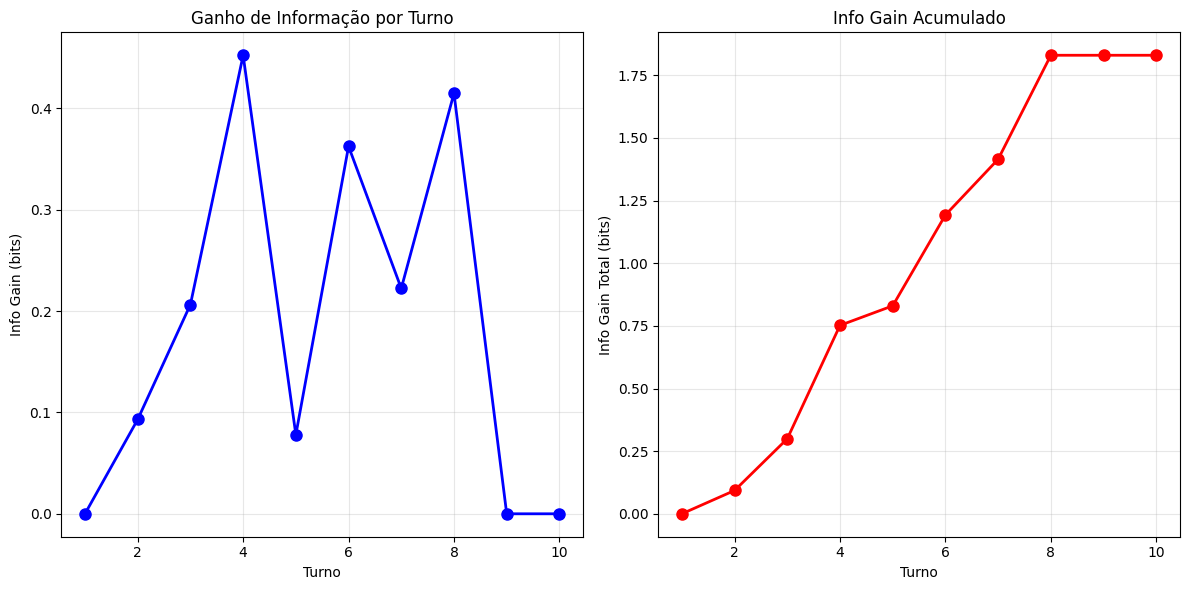

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Se você ainda não carregou os dados, use:
# df = pd.read_json("path/to/turns.jsonl", lines=True)

# 1. Plot básico do info_gain por turno
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(df['turn_index'], df['info_gain'], 'bo-', linewidth=2, markersize=8)
plt.title('Ganho de Informação por Turno')
plt.xlabel('Turno')
plt.ylabel('Info Gain (bits)')
plt.grid(True, alpha=0.3)

# 2. Plot com info_gain acumulado
plt.subplot(1, 2, 2)
df['cumulative_info_gain'] = df['info_gain'].cumsum()
plt.plot(df['turn_index'], df['cumulative_info_gain'], 'ro-', linewidth=2, markersize=8)
plt.title('Info Gain Acumulado')
plt.xlabel('Turno')
plt.ylabel('Info Gain Total (bits)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob

# Carregar todos os games
conversations_dir = "/Users/daniel2/Documents/AKCIT-RL/clary_quest/outputs/models/s_qwen3-8b__o_gpt-4o-mini__p_gpt-4o-mini/top40_po/conversations"
turns_files = glob.glob(f"{conversations_dir}/game_*/turns.jsonl")

all_data = []
for file in turns_files:
    df = pd.read_json(file, lines=True)
    game_id = Path(file).parent.name
    df['game_id'] = game_id
    all_data.append(df)

combined_df = pd.concat(all_data, ignore_index=True)

# Calcular média por turno
avg_per_turn = combined_df.groupby('turn_index')['info_gain'].agg(['mean', 'std', 'count']).reset_index()

# Plotar
plt.figure(figsize=(12, 6))
plt.errorbar(
    avg_per_turn['turn_index'], 
    avg_per_turn['mean'], 
    # yerr=avg_per_turn['std'], 
    capsize=5, 
    marker='o', 
    linewidth=2, 
    markersize=8
    )
plt.title('Ganho Médio de Informação por Turno')
plt.xlabel('Turno')
plt.ylabel('Info Gain Médio (bits)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Analisados {combined_df['game_id'].nunique()} games")
avg_per_turn

ValueError: No objects to concatenate